<a href="https://colab.research.google.com/github/mamoo9811/ML-Data/blob/main/Use_CDF_to_Calculate_Probabilities_(Core).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
import scipy.stats as stats

fname = "https://docs.google.com/spreadsheets/d/1KladkGyedZzPXuESDLgnU49t4bbl0wJrrO-LaFFpseE/gviz/tq?tqx=out:csv&gid=0"
df = pd.read_csv(fname)
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [30]:
males = df.loc[ df['Gender'] == 'Male'].copy()
females = df.loc[ df['Gender'] == 'Female'].copy()

In [31]:
data = females['Height']
mean = np.mean(data)
std = np.std(data)

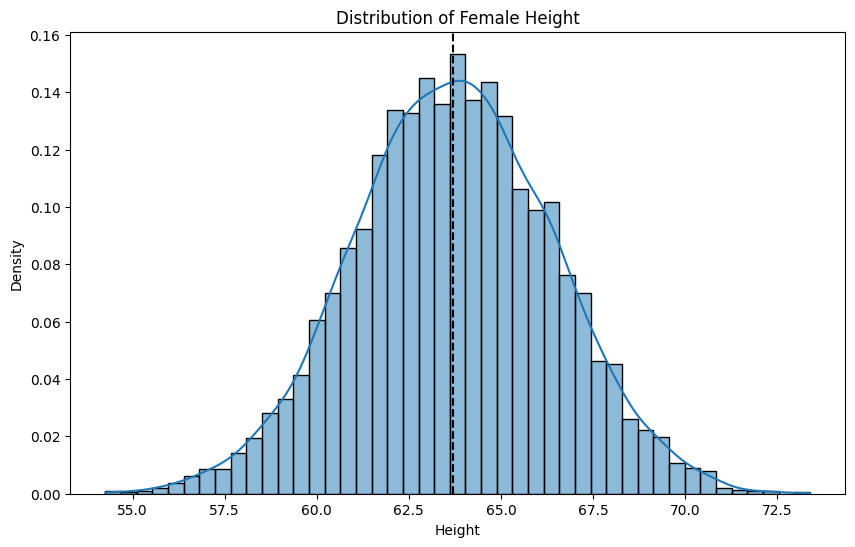

In [35]:
fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(x=data, stat='density',kde=True,cumulative=False)
ax.set_title('Distribution of Female Height')
ax.axvline(mean,color='k',ls='--', label=f"Mean: {mean:.2f}")

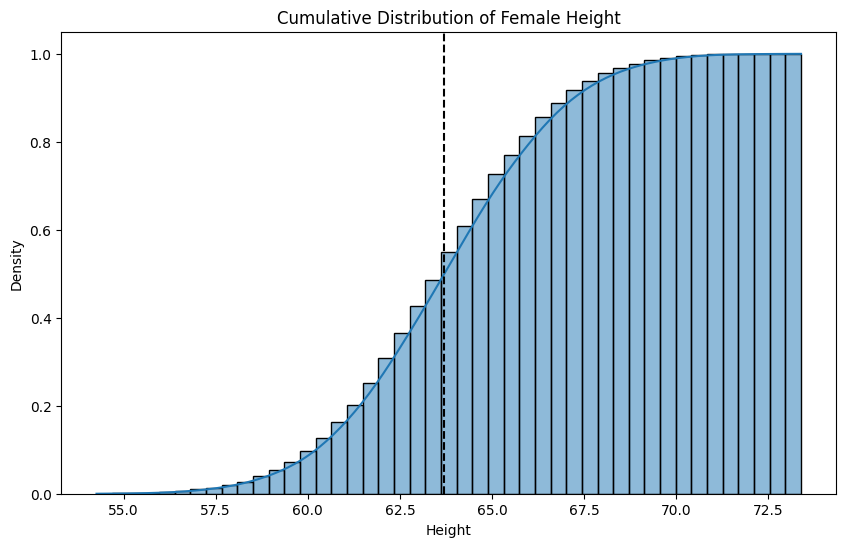

In [36]:
fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(x=data, stat='density',kde=True,cumulative=True)
ax.set_title('Cumulative Distribution of Female Height')
ax.axvline(mean,color='k',ls='--');

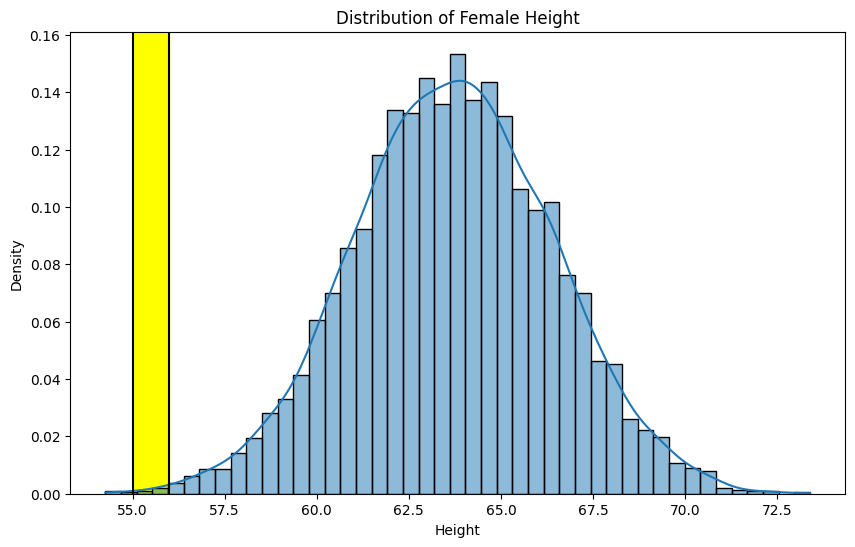

In [37]:
low_end = 55.0
high_end = 56.0
fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(x=data, stat='density',kde=True)
ax.set_title('Distribution of Female Height')
ax.axvline(low_end, color= 'black')
ax.axvline(high_end, color ='black')
ax.axvspan(low_end, high_end, color ='yellow', zorder = 0);

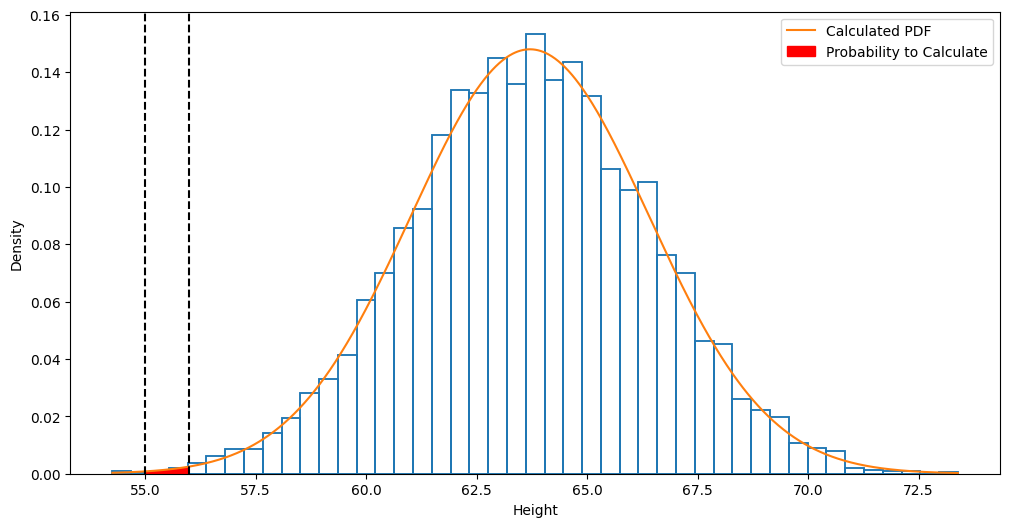

In [41]:
min_val = np.min(data)
max_val = np.max(data)
range_vals = np.linspace(min_val, max_val,1000)
pdf = stats.norm.pdf(range_vals,loc=mean,scale=std)
fig, ax = plt.subplots(figsize=(12,6))
sns.histplot(x=data, fill=False,stat='density',ax=ax)
ax.plot(range_vals,pdf,label='Calculated PDF')
ax.axvline(55,color='k',ls='--')
ax.axvline(56,color='k',ls='--')
ax.fill_between(range_vals,pdf, where=(range_vals>55)&(range_vals<56),
                color='red', label='Probability to Calculate')
ax.legend();

In [42]:
stats.norm.cdf(56, loc=mean,scale=std) - stats.norm.cdf(55,loc=mean, scale=std)

np.float64(0.0015043054289559897)

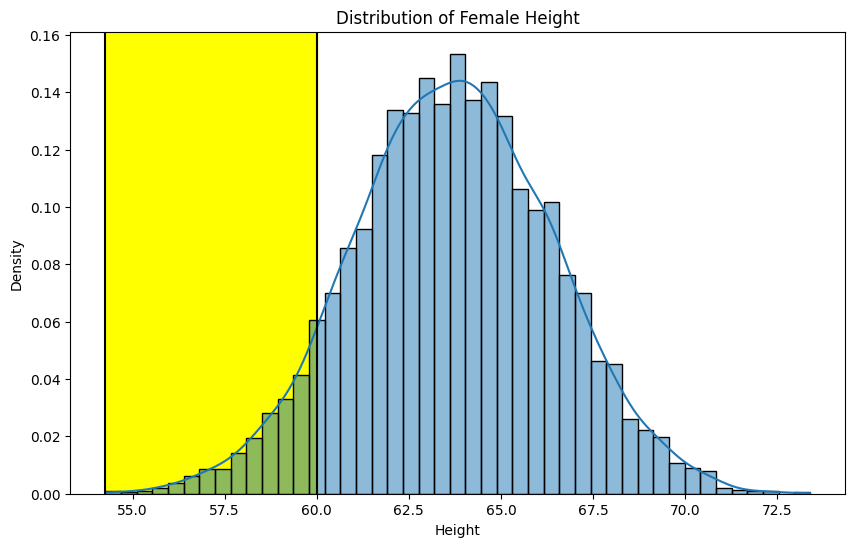

In [43]:
low_end = min_val
high_end = 60


fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(x=data, stat='density',kde=True)
ax.set_title('Distribution of Female Height')
ax.axvline(low_end, color= 'black')
ax.axvline(high_end, color ='black')
ax.axvspan(low_end, high_end, color ='yellow', zorder = 0);

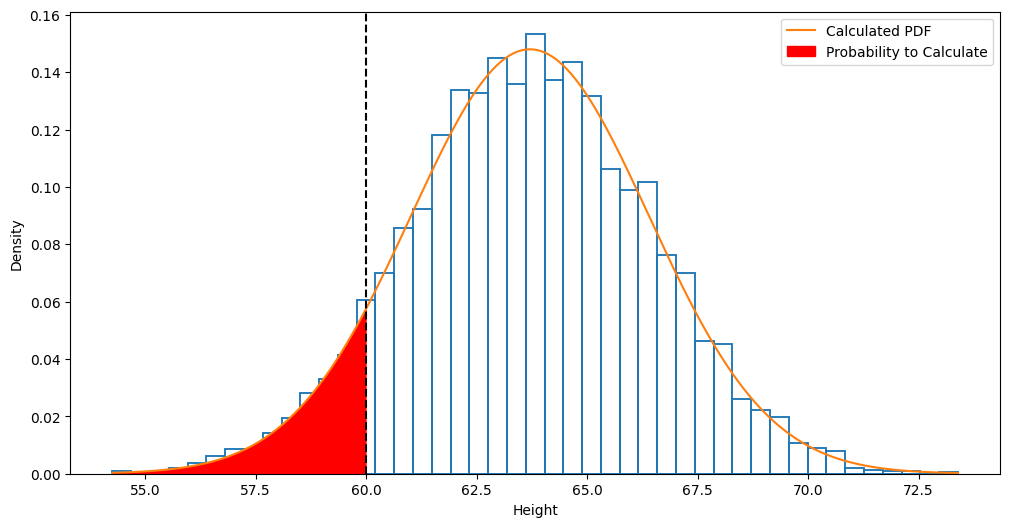

In [44]:
pdf = stats.norm.pdf(range_vals,loc=mean,scale=std)
fig, ax = plt.subplots(figsize=(12,6))
sns.histplot(x=data, fill=False,stat='density',ax=ax)
ax.plot(range_vals,pdf,label='Calculated PDF')
ax.axvline(60,color='k',ls='--')
ax.fill_between(range_vals,pdf, where=(range_vals>min_val)&(range_vals<60),
                color='red', label='Probability to Calculate')
ax.legend();

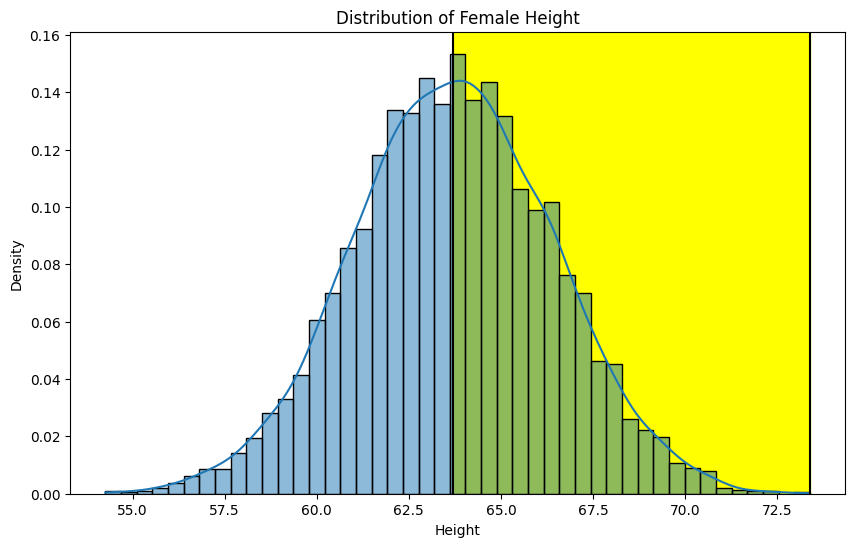

In [45]:
low_end = mean
high_end = max_val

fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(x=data, stat='density',kde=True)
ax.set_title('Distribution of Female Height')
ax.axvline(low_end, color= 'black')
ax.axvline(high_end, color ='black')
ax.axvspan(low_end, high_end, color ='yellow', zorder = 0);

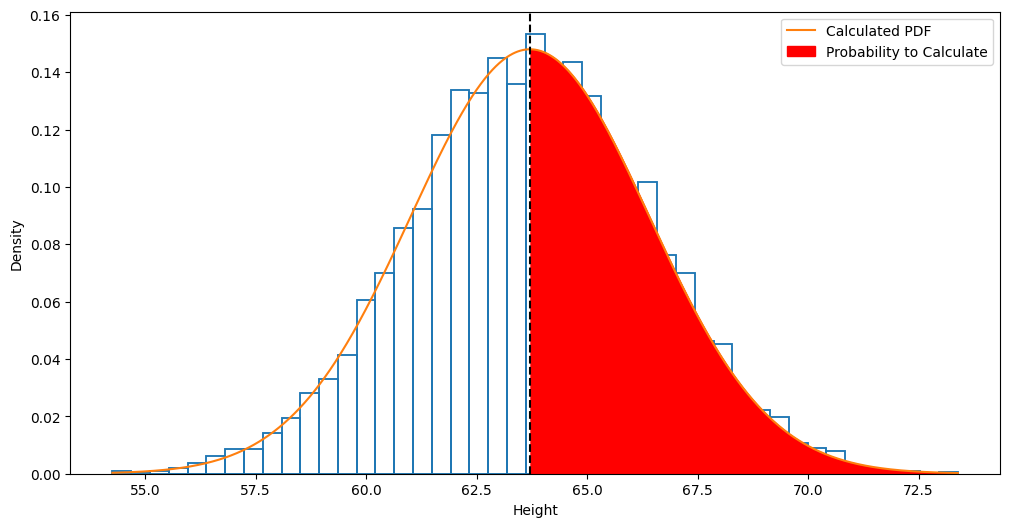

In [48]:
pdf = stats.norm.pdf(range_vals,loc=mean,scale=std)
fig, ax = plt.subplots(figsize=(12,6))
sns.histplot(x=data, fill=False,stat='density',ax=ax)
ax.plot(range_vals,pdf,label='Calculated PDF')
ax.axvline(mean,color='k',ls='--')
ax.fill_between(range_vals,pdf, where=(range_vals>mean)&(range_vals<max_val),
                color='red', label='Probability to Calculate')
ax.legend();

In [47]:
prob = 1 - (stats.norm.cdf(mean, loc=np.mean(data), scale= np.std(data)))
prob

np.float64(0.5)